In [2]:
import braid_analysis

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pandas as pd

from braid_analysis import braid_filemanager
from braid_analysis import braid_2d_analysis as b2d

# Data folder

In [2]:
data_folder = '/Users/florisvb/src/braid_2d_3d_data/20260313_WT_motion_stim_split_node'
window_s    = 5.0   # seconds before/after each trigger to load and analyse

# Load experiment config and trigger events

In [3]:
exp_code    = b2d.load_exp_code(data_folder)
df_triggers = b2d.load_triggers(data_folder, exp_code)

print(f'Triggers loaded: {len(df_triggers)}')
print('Trigger counts per stimulus condition:')
print(df_triggers.groupby(exp_code['column_names']).size().reset_index(name='count').to_string(index=False))

Triggers loaded: 616
Trigger counts per stimulus condition:
 flash_duration  visual_motion_direction  visual_motion_speed  visual_motion_duration  count
            0.0                      0.0                  0.2                     5.0    334
            0.0                    180.0                  0.0                     5.0    282


# Load 3D data and the 2D data windowed around triggers

In [4]:
braidz_filename = b2d.get_filename(data_folder, '.braidz')

# Full 3D data (fast to load)
df_3d = braid_filemanager.load_filename_as_dataframe_3d(braidz_filename)
print('3D data shape:', df_3d.shape)

3D data shape: (6958477, 18)


In [5]:
# Build the set of frames within ±window_s of any trigger, then load only those 2D rows
wanted_frames  = b2d.build_trigger_frame_window(df_triggers, df_3d, window_s=window_s)
df_2d_windowed = b2d.load_2d_for_frames(braidz_filename, wanted_frames)
print(f'Frames in window: {len(wanted_frames)},  2D rows loaded: {len(df_2d_windowed)}')

Frames in window: 596709,  2D rows loaded: 15827662


# Load camera calibration

In [6]:
camn_to_P, camn_to_id, camn_to_res = b2d.load_calibration(braidz_filename)
print(f'Cameras: {len(camn_to_P)}')
for camn, cam_id in sorted(camn_to_id.items()):
    print(f'  camn {camn:3d}  {cam_id}')

Cameras: 20
  camn  20  Basler-40196688
  camn  21  Basler-40196689
  camn  22  Basler-40196690
  camn  23  Basler-40196691
  camn  24  Basler-40196692
  camn  25  Basler-40196693
  camn  26  Basler-40196694
  camn  27  Basler-40196695
  camn  28  Basler-40196696
  camn  29  Basler-40196697
  camn  30  Basler-40196698
  camn  31  Basler-40196699
  camn  32  Basler-40196700
  camn  33  Basler-40196701
  camn  34  Basler-40196703
  camn  35  Basler-40450770
  camn  36  Basler-40450771
  camn  37  Basler-40450773
  camn  38  Basler-40450774
  camn  39  Basler-40450776


# Single trigger event: 3D x-position and 2D detections vs time

In [7]:
trigger_idx = 2  # change to explore different events

trigger    = df_triggers.iloc[trigger_idx]
t_trigger  = trigger['t']
triggered_obj_id = b2d.find_triggered_obj_id(t_trigger, df_3d, exp_code)

print(f'Trigger #{trigger_idx}  t={t_trigger:.1f}  obj_id={triggered_obj_id}')
print(trigger.to_string())

Trigger #2  t=1773445522.8  obj_id=67
data_0                     1.000000e+00
data_1                     6.700000e+01
data_2                     4.928500e+04
data_3                     1.773446e+09
flash_duration             0.000000e+00
visual_motion_direction    1.800000e+02
visual_motion_speed        0.000000e+00
visual_motion_duration     5.000000e+00
t_secs                     1.773446e+09
t_nsecs                    8.067318e+08
t                          1.773446e+09


Trigger #2  t=1773445522.8  obj_id=67
data_0                     1.000000e+00
data_1                     6.700000e+01
data_2                     4.928500e+04
data_3                     1.773446e+09
flash_duration             0.000000e+00
visual_motion_direction    1.800000e+02
visual_motion_speed        0.000000e+00
visual_motion_duration     5.000000e+00
t_secs                     1.773446e+09
t_nsecs                    8.067318e+08
t                          1.773446e+09


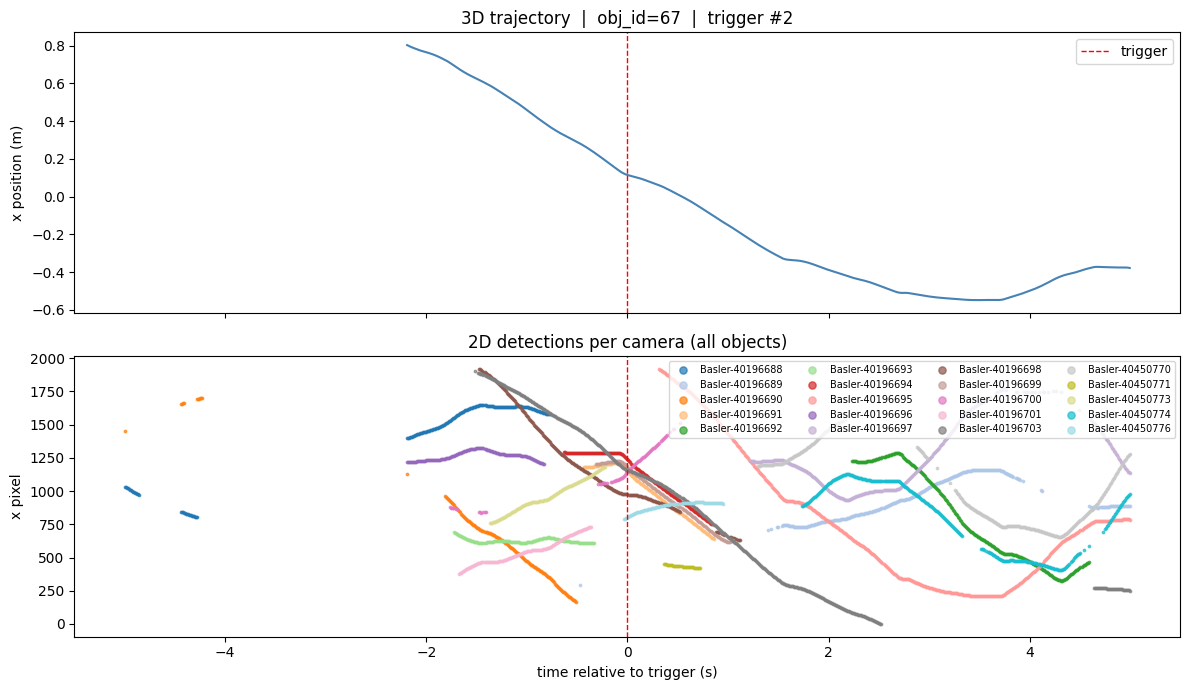

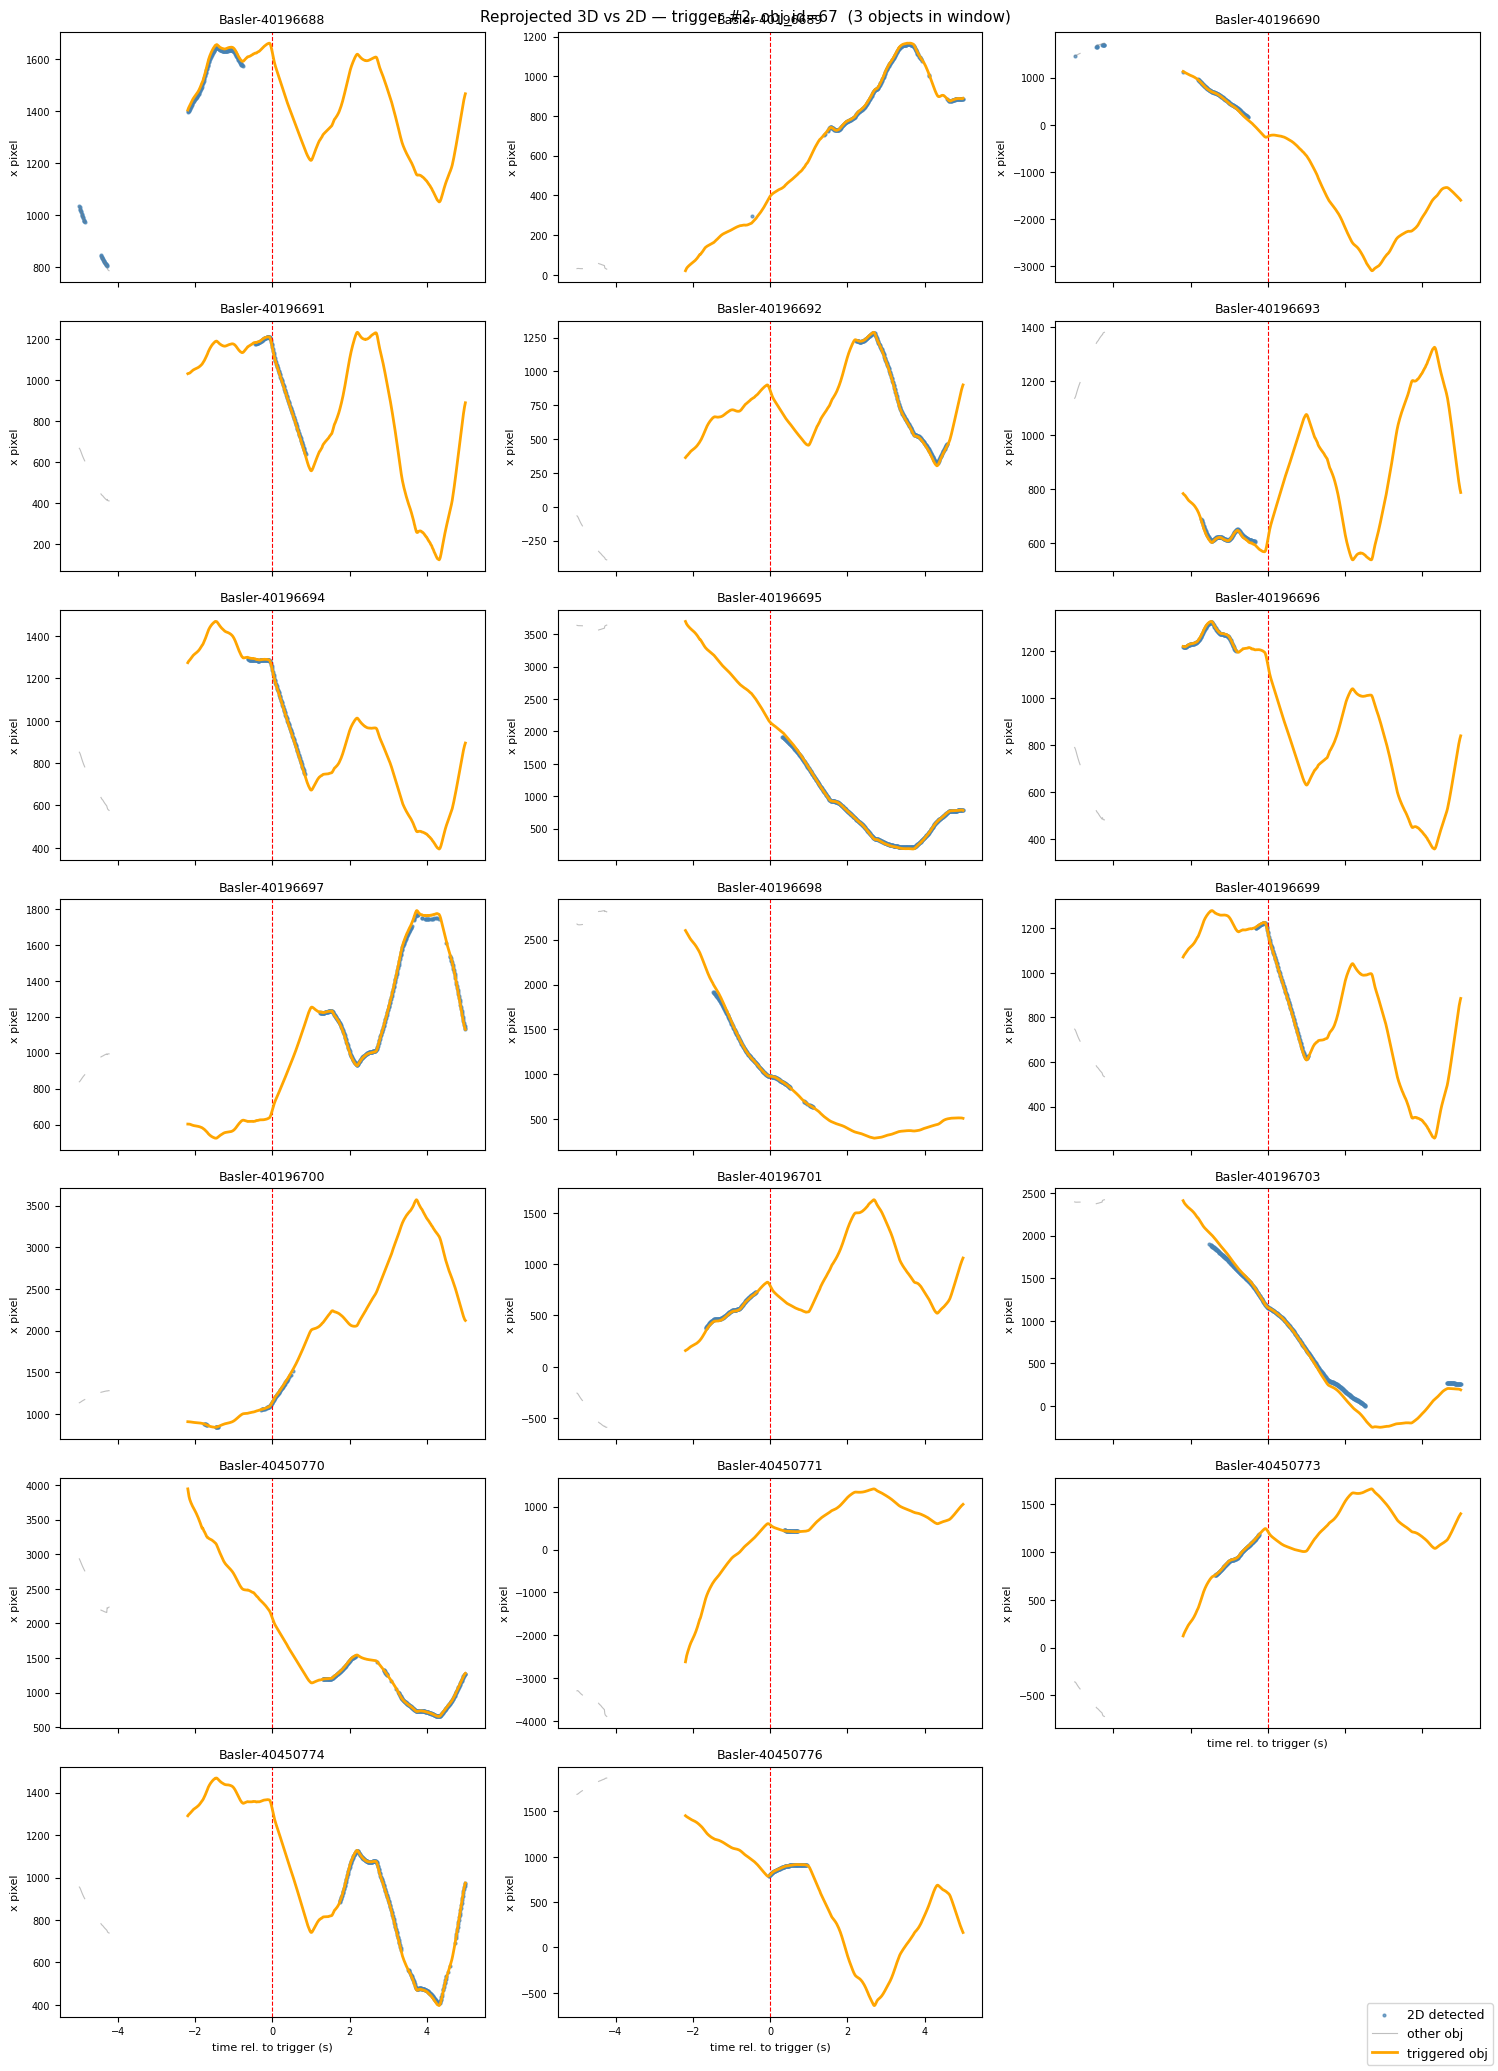

In [8]:
b2d.plot_single_trigger_event(
    trigger_idx, df_triggers, df_3d, df_2d_windowed,
    exp_code, camn_to_P, camn_to_id, window_s=window_s)

# Reproject all 3D objects into each camera view

# Meta-analysis across all trigger events
Set `n_triggers = None` to run on the full dataset.

In [9]:
n_triggers         = 100     # set to None to run all triggers
distance_threshold = 30    # pixels
bins = np.linspace(-window_s, window_s, 60)

In [10]:
start_times, stop_times = b2d.compute_3d_start_stop_times(
    df_triggers, df_3d, exp_code, window_s=window_s, n_triggers=n_triggers)

corr_times = b2d.compute_2d_correspondence_times(
    df_triggers, df_3d, df_2d_windowed, camn_to_P, camn_to_res, exp_code,
    window_s=window_s, distance_threshold=distance_threshold, n_triggers=n_triggers)

compute_3d_start_stop_times: 78 trajectories found (of 100 triggers)
compute_2d_correspondence_times: processed 100 triggers


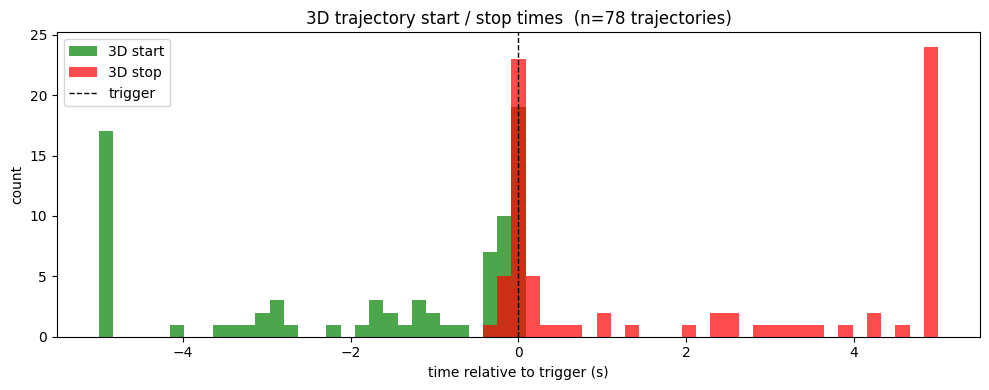

In [11]:
b2d.plot_3d_start_stop_histogram(start_times, stop_times, window_s)

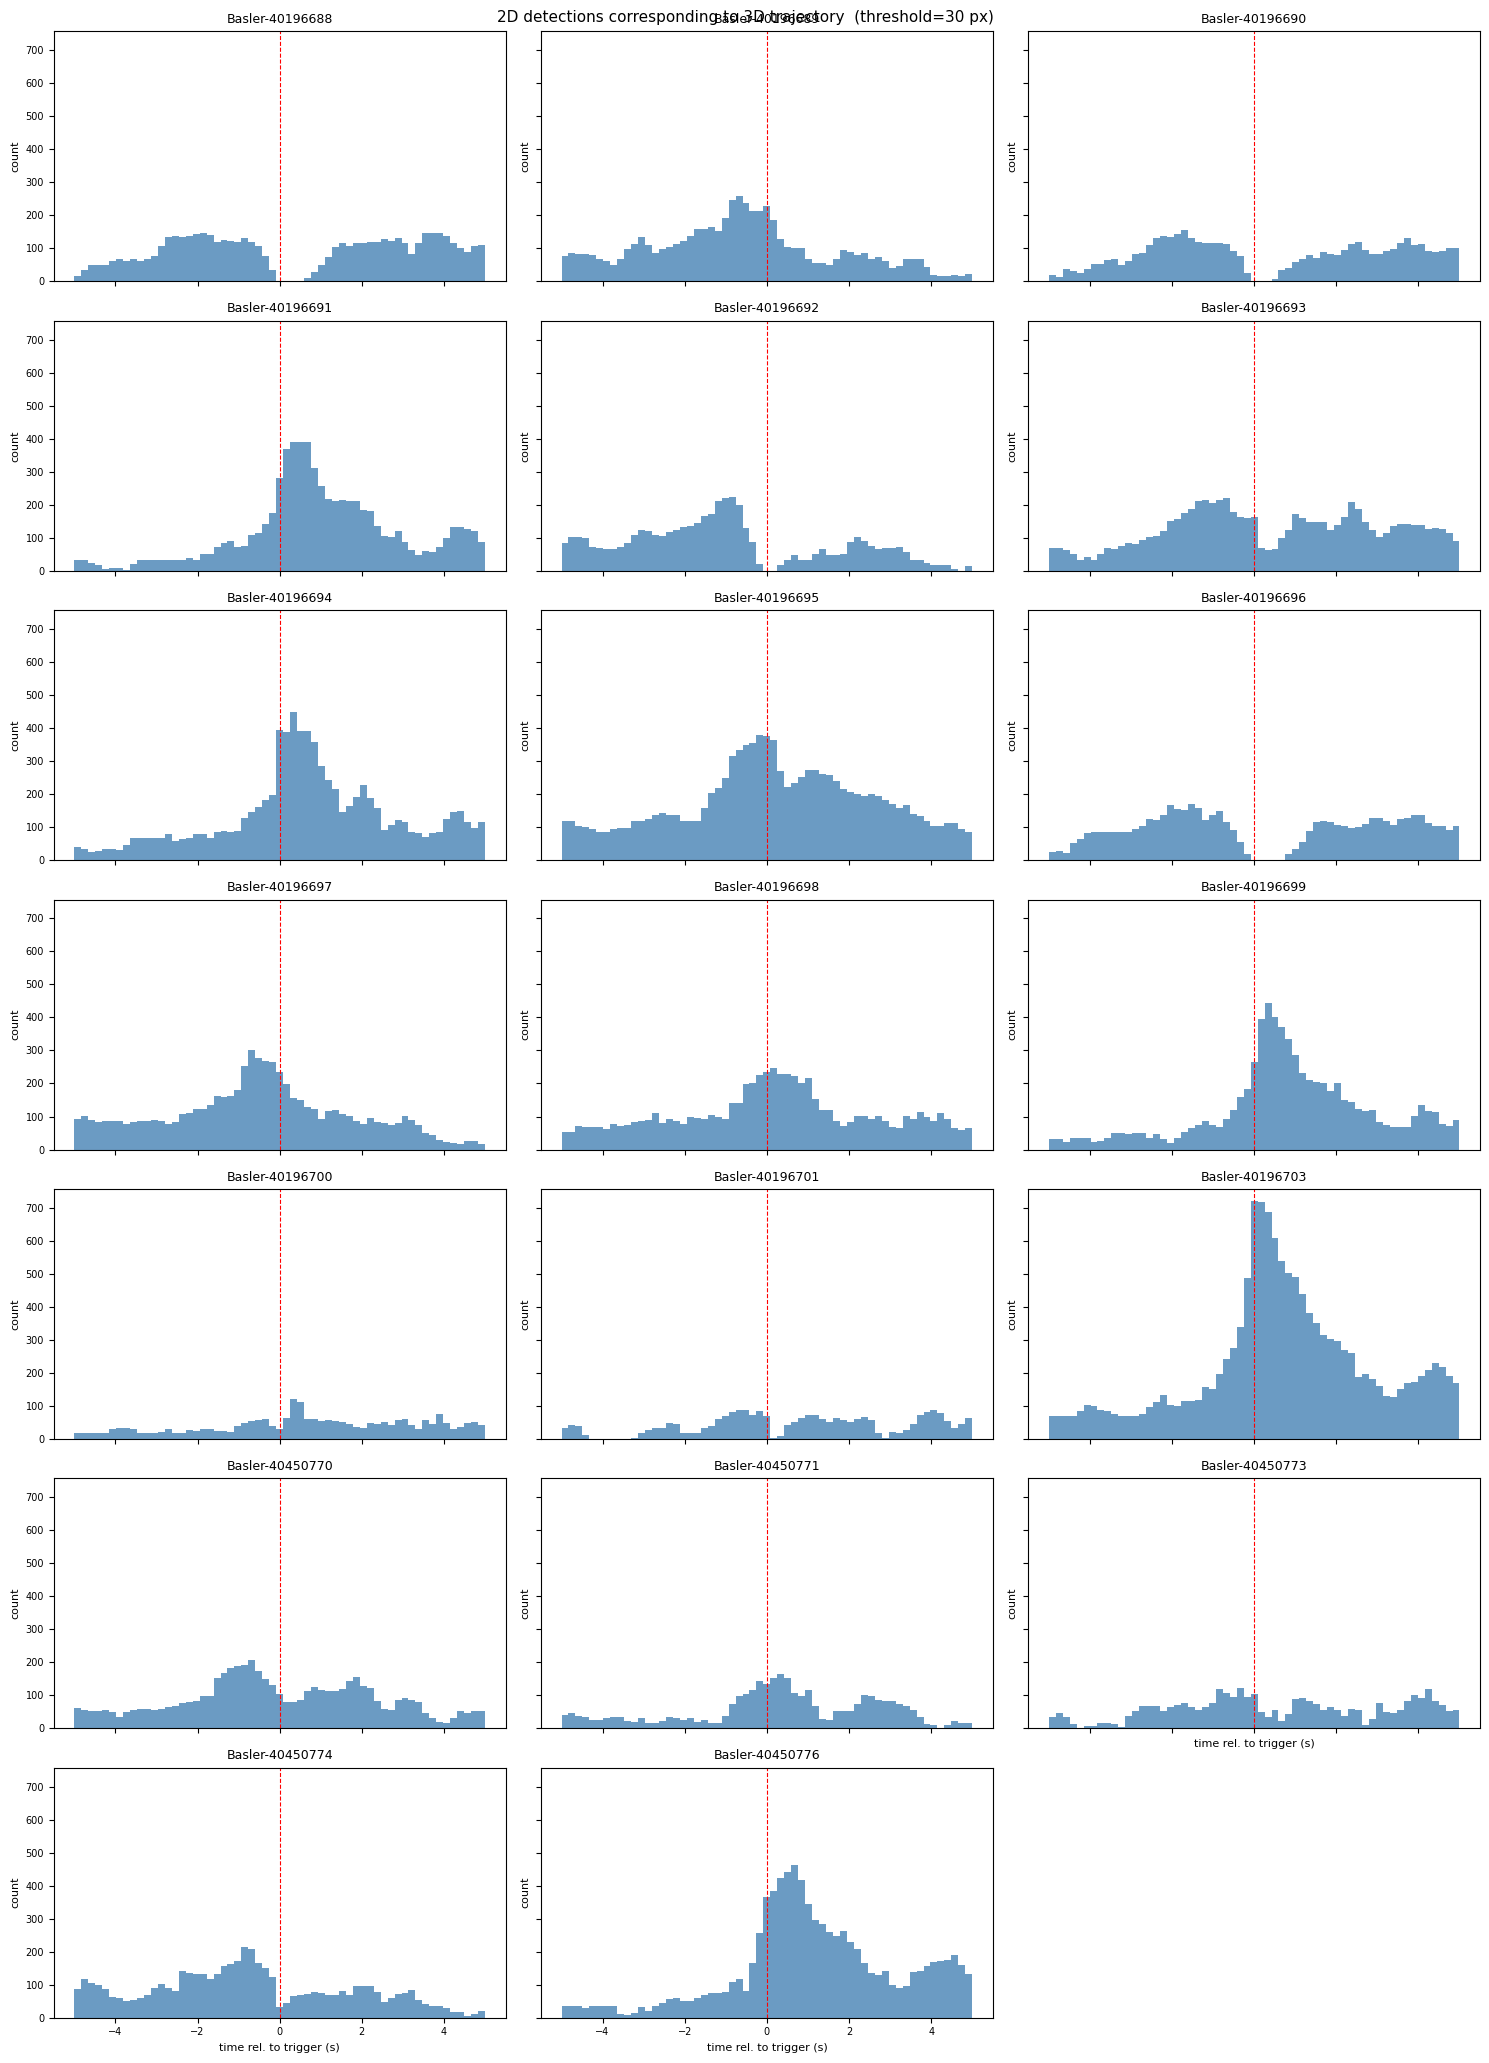

In [12]:
b2d.plot_2d_correspondence_histograms(corr_times, camn_to_id, window_s, distance_threshold)

# 2D pixel locations of trajectory correspondences per camera

In [13]:
corr_pixels = b2d.compute_2d_correspondence_pixels(
    df_triggers, df_3d, df_2d_windowed, camn_to_P, camn_to_res, exp_code,
    window_s=window_s, distance_threshold=distance_threshold, n_triggers=n_triggers)

compute_2d_correspondence_pixels: done (100 triggers)


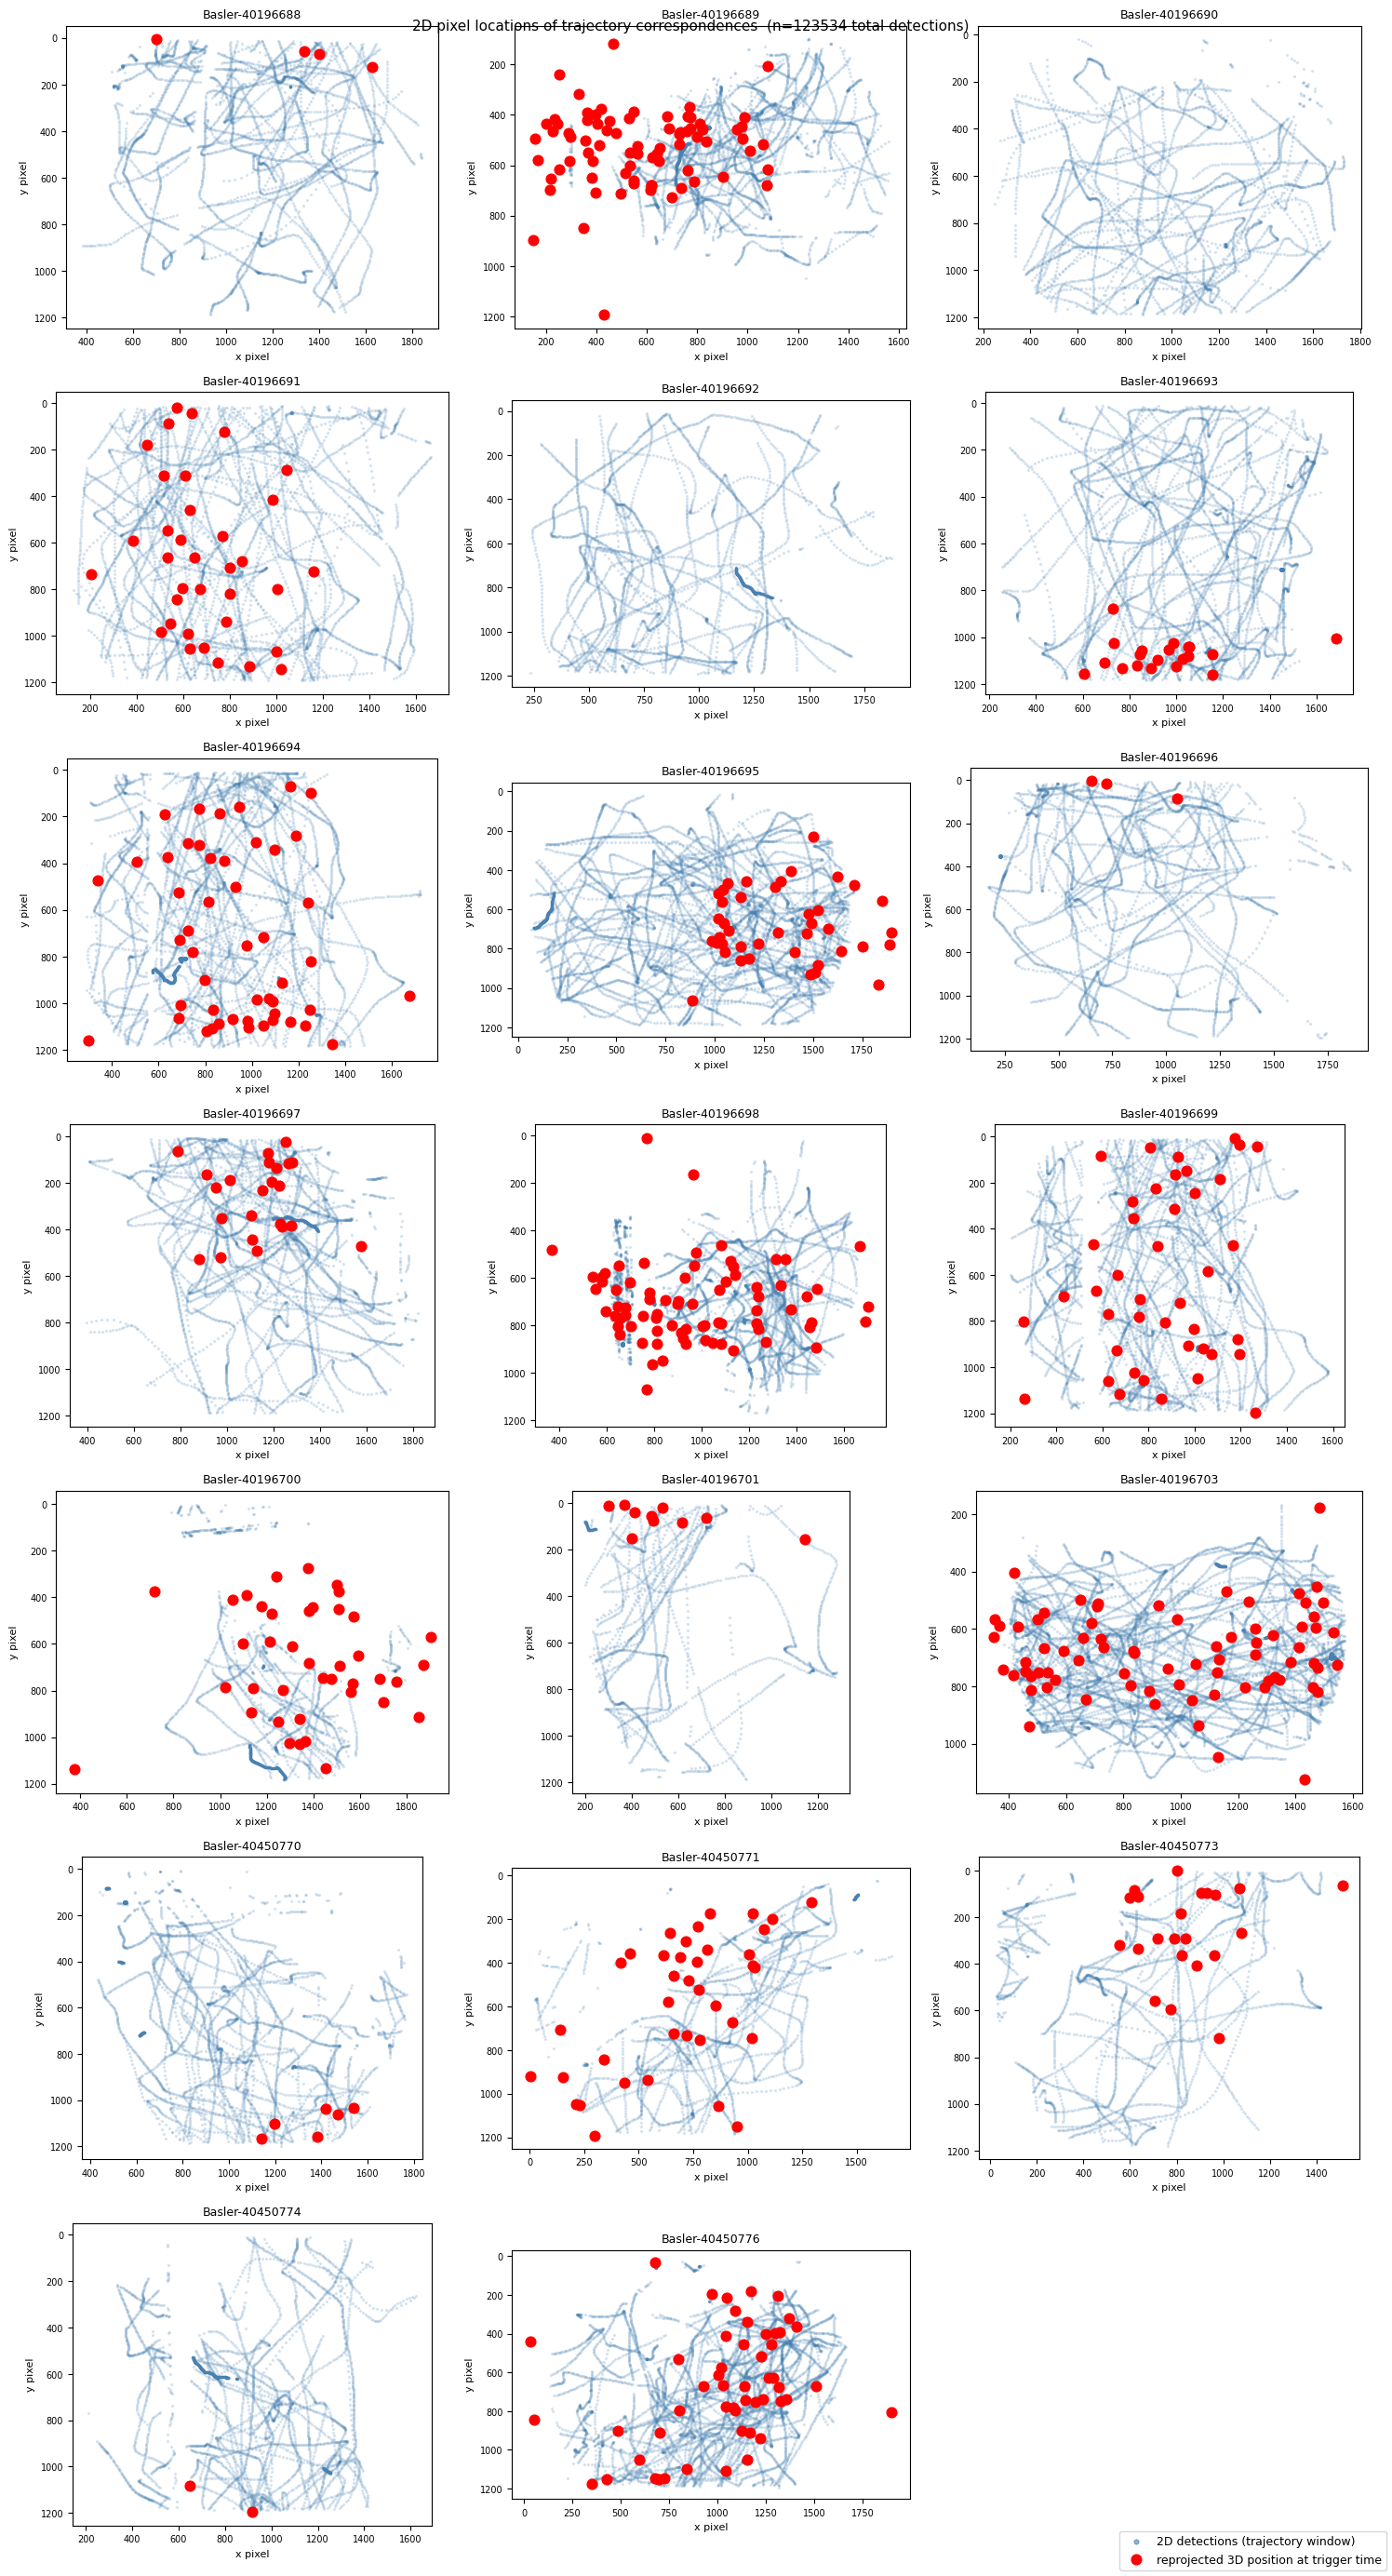

In [14]:
b2d.plot_2d_pixel_locations(corr_pixels, camn_to_id, ncols=3, alpha=0.15, point_size=2)